In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.metrics import accuracy_score

print("Building Perceptron from scratch")
print("The simplest neural network — one neuron, one layer")

Building Perceptron from scratch
The simplest neural network — one neuron, one layer


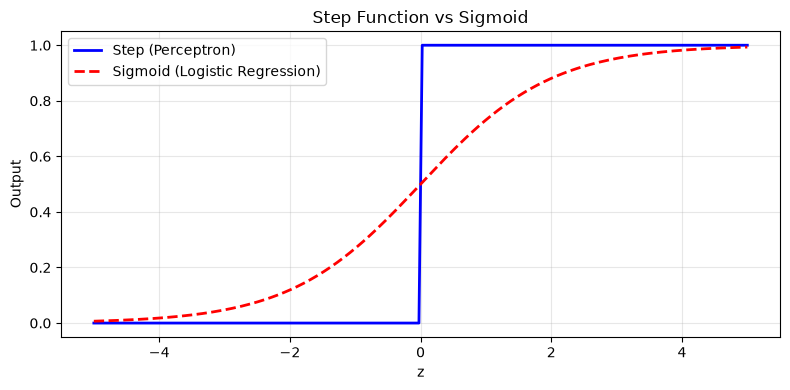

In [2]:
# ============================================================
# THE MATH BEHIND THE PERCEPTRON
# ============================================================
#
# The Perceptron (1958, Frank Rosenblatt) is the simplest
# possible neural network: one neuron.
#
# Model:
#   z = X @ w + b                    (weighted sum)
#   y_hat = step_function(z)         (1 if z >= 0, else 0)
#
# Update rule (Perceptron Learning Rule):
#   If prediction is correct: do nothing
#   If prediction is wrong:
#     w = w + lr * (y - y_hat) * x
#     b = b + lr * (y - y_hat)
#
# Key difference from Logistic Regression:
#   - Uses step function (hard 0/1) instead of sigmoid (soft probability)
#   - No cost function to minimize
#   - Guaranteed to converge IF data is linearly separable
#   - Will NOT converge if data is not linearly separable
# ============================================================

# Visualize step function vs sigmoid
z = np.linspace(-5, 5, 200)
step = np.where(z >= 0, 1, 0)
sigmoid_val = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 4))
plt.plot(z, step, 'b-', linewidth=2, label='Step (Perceptron)')
plt.plot(z, sigmoid_val, 'r--', linewidth=2, label='Sigmoid (Logistic Regression)')
plt.xlabel('z')
plt.ylabel('Output')
plt.title('Step Function vs Sigmoid')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [3]:
# ============================================================
# PERCEPTRON FROM SCRATCH
# ============================================================

class PerceptronScratch:

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.weights = None
        self.bias = None
        self.errors_per_epoch = []
    
    def _step_function(self, z):
        """Hard threshold: 1 if z >= 0, else 0"""
        return np.where(z >= 0, 1, 0)
    
    def fit(self, X, y):
        """Train perceptron using the perceptron learning rule"""
        n_samples, n_features = X.shape
        
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.errors_per_epoch = []
        
        for epoch in range(self.n_iter):
            errors = 0
            
            for i in range(n_samples):
                # Forward pass
                z = X[i] @ self.weights + self.bias
                y_hat = self._step_function(z)
                
                # Update only if wrong
                error = y[i] - y_hat
                if error != 0:
                    self.weights += self.lr * error * X[i]
                    self.bias += self.lr * error
                    errors += 1
            
            self.errors_per_epoch.append(errors)
            
            # Early stopping if no errors
            if errors == 0:
                print(f"Converged at epoch {epoch + 1} (zero errors)")
                break
        
        return self
    
    def predict(self, X):
        z = X @ self.weights + self.bias
        return self._step_function(z)
    
    def score(self, X, y):
        return np.mean(self.predict(X) == y)

print("PerceptronScratch class defined")
print("Methods: fit(), predict(), score()")

PerceptronScratch class defined
Methods: fit(), predict(), score()


In [4]:
# ============================================================
# GENERATE LINEARLY SEPARABLE DATA
# ============================================================

np.random.seed(42)

X, y = make_classification(
    n_samples=300, n_features=2, n_redundant=0,
    n_informative=2, n_clusters_per_class=1,
    class_sep=2.0, random_state=42  # large separation
)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = PerceptronScratch(learning_rate=0.01, n_iterations=100)
model.fit(X_train, y_train)

print(f"\nWeights: {np.round(model.weights, 4)}")
print(f"Bias:    {model.bias:.4f}")
print(f"Train accuracy: {model.score(X_train, y_train) * 100:.1f}%")
print(f"Test accuracy:  {model.score(X_test, y_test) * 100:.1f}%")

Converged at epoch 55 (zero errors)

Weights: [-0.0085  0.1507]
Bias:    0.0600
Train accuracy: 100.0%
Test accuracy:  100.0%


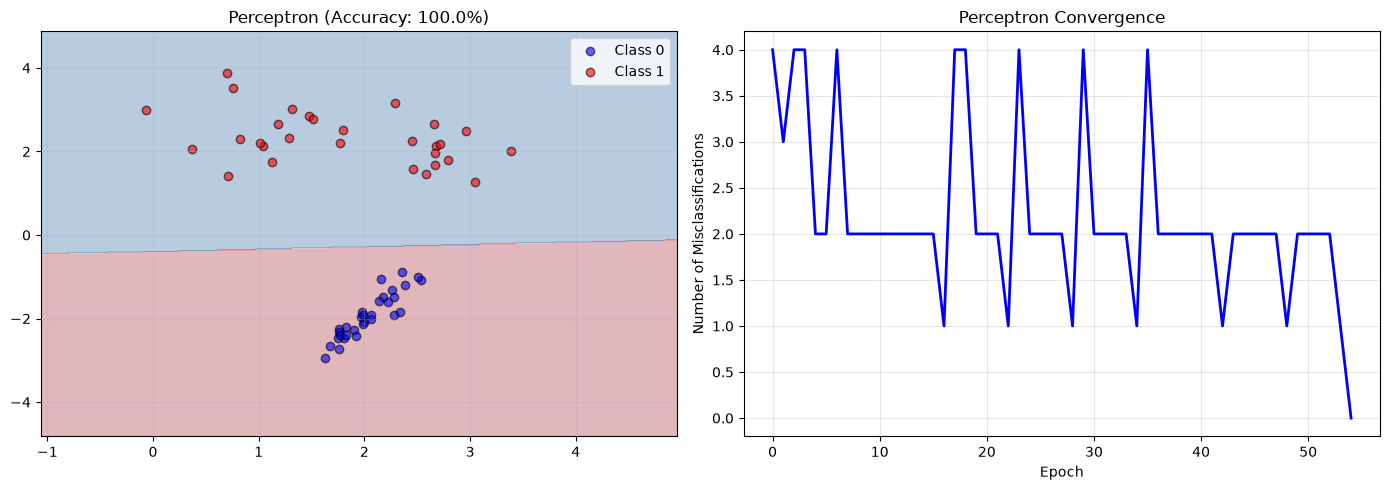

In [5]:
# ============================================================
# VISUALIZE: DECISION BOUNDARY + CONVERGENCE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                      np.arange(y_min, y_max, 0.02))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

axes[0].contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
axes[0].scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1],
                c='blue', label='Class 0', alpha=0.6, edgecolors='k')
axes[0].scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1],
                c='red', label='Class 1', alpha=0.6, edgecolors='k')
axes[0].set_title(f'Perceptron (Accuracy: {model.score(X_test, y_test)*100:.1f}%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Errors per epoch
axes[1].plot(model.errors_per_epoch, 'b-', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Number of Misclassifications')
axes[1].set_title('Perceptron Convergence')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('perceptron_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ============================================================
# COMPARE WITH SCIKIT-LEARN
# ============================================================

sklearn_model = SklearnPerceptron(max_iter=100, random_state=42)
sklearn_model.fit(X_train, y_train)

print(f"{'Metric':<20} {'From Scratch':>15} {'Scikit-Learn':>15}")
print(f"{'-'*50}")
print(f"{'Train Accuracy':<20} {model.score(X_train, y_train)*100:>14.1f}% {sklearn_model.score(X_train, y_train)*100:>14.1f}%")
print(f"{'Test Accuracy':<20} {model.score(X_test, y_test)*100:>14.1f}% {sklearn_model.score(X_test, y_test)*100:>14.1f}%")

Metric                  From Scratch    Scikit-Learn
--------------------------------------------------
Train Accuracy                100.0%           99.2%
Test Accuracy                 100.0%          100.0%



XOR accuracy: 50.0%
Perceptron CANNOT solve XOR — this motivated multi-layer networks.
The solution: add hidden layers → this becomes a neural network.


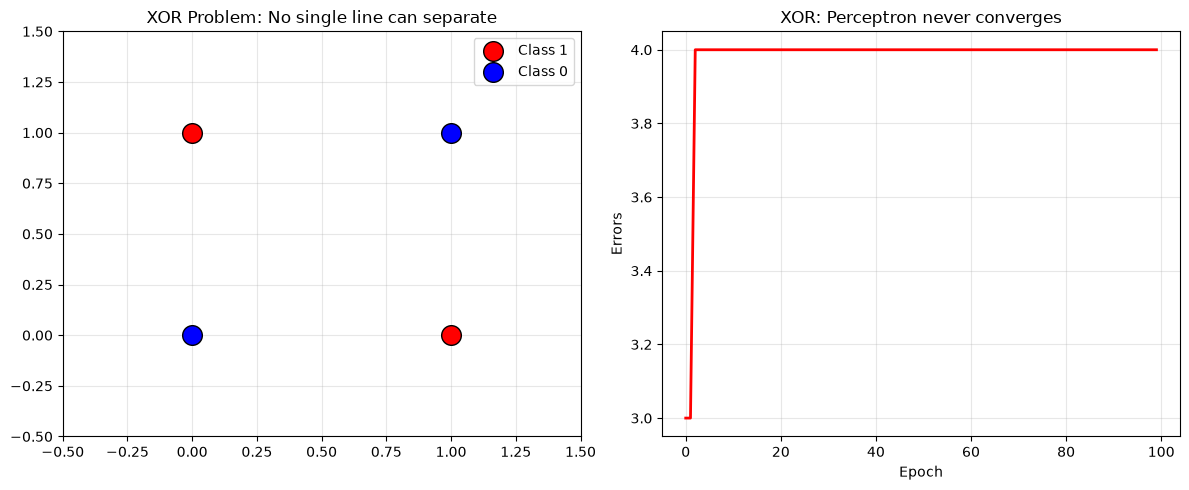

In [7]:
# ============================================================
# DEMONSTRATE FAILURE ON NON-SEPARABLE DATA (XOR PROBLEM)
# ============================================================

# XOR data: cannot be separated by a single line
X_xor = np.array([[0,0], [0,1], [1,0], [1,1]])
y_xor = np.array([0, 1, 1, 0])

model_xor = PerceptronScratch(learning_rate=0.1, n_iterations=100)
model_xor.fit(X_xor, y_xor)

print(f"\nXOR accuracy: {model_xor.score(X_xor, y_xor) * 100:.1f}%")
print("Perceptron CANNOT solve XOR — this motivated multi-layer networks.")
print("The solution: add hidden layers → this becomes a neural network.")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# XOR data
axes[0].scatter([0,1], [1,0], c='red', s=200, label='Class 1', edgecolors='k', zorder=5)
axes[0].scatter([0,1], [0,1], c='blue', s=200, label='Class 0', edgecolors='k', zorder=5)
axes[0].set_title('XOR Problem: No single line can separate')
axes[0].set_xlim(-0.5, 1.5)
axes[0].set_ylim(-0.5, 1.5)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Errors never reach zero
axes[1].plot(model_xor.errors_per_epoch, 'r-', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Errors')
axes[1].set_title('XOR: Perceptron never converges')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('perceptron_xor_failure.png', dpi=150, bbox_inches='tight')
plt.show()